# Esame Laboratorio di Programmazione II - 03/02/2026


Scrivete chiaramente sul notebook il vostro nome e matricola e salvate il file con il nome della vostra matricola.

Per ogni funzione e metodo che richiede un campionamento rispetto ad una distribuzione settate il seed a 0: ``np.random.seed(0)``.

Stampate il risultato delle domanda e consegnate il compito eseguito, ogni cella deve avere il corrispondente output.
Quindi ad esempio

e.g., 
NON scrivete: 
```python 
    lista=np.array([1,2,3])
```
ma 
```python
    lista=np.array([1,2,3]) 
    print('lista =', lista)   
```
Attenzione!Se scrivete:
```python
    lista=np.array([1,2,3])
    lista
```
``lista`` sarà l'unico ouput che si vede di quella cella

NB se l'output è una matrice molto grande non dovete stamparla.

Sarà valutata anche la presentazione, ad esempio un plot senza ettichette sugli assi o illleggibili sarà valutato meno bene di uno con ettichette chiare.

Commentate il compito di modo che si capisca cosa avete fatto.

Controllate attentamente di avere consegnato il file giusto.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Esercizio 1

Un sensore ha registrato le seguenti misure (in unità arbitrarie) in 15 istanti consecutivi:

`12, 15, 14, 18, 21, 19, 17, 16, 22, 25, 20, 18, 16, 15, 14`

1. Crea un array NumPy `x` con questi valori e calcola la **media**.
2. Per un problema di calibrazione, tutte le misure **strettamente maggiori di 18** devono essere **ridotte di 2**. Aggiorna l’array (in-place) e stampa il nuovo array.  
3. Calcola quanti valori, dopo la correzione, risultano **compresi tra 14 e 18 inclusi**.  


In [6]:
x = np.array([12, 15, 14, 18, 21, 19, 17, 16, 22, 25, 20, 18, 16, 15, 14])
print(f"Array originale: {x}\n")
media = x.mean()
print(f"Media array originale: {media}\n")
x = np.where(x > 18, x-2, x)
print(f"Array con calibrazione: {x}\n")
n = np.sum((x > 14) & (x < 18))
print(f"Numeri tali che 14 < x < 18: {n}")

Array originale: [12 15 14 18 21 19 17 16 22 25 20 18 16 15 14]

Media array originale: 17.466666666666665

Array con calibrazione: [12 15 14 18 19 17 17 16 20 23 18 18 16 15 14]

Numeri tali che 14 < x < 18: 6


## Esercizio 2

Un dado **truccato** ha probabilità **doppia** di uscire 6 rispetto agli altri numeri.

In particolare:
- la probabilità di ottenere ciascun numero da **1 a 5** è **1/7**
- la probabilità di ottenere **6** è **2/7**

1. Scrivi una funzione `lanci_dado(N)` che simula `N` lanci del dado e restituisce
   un array NumPy contenente i risultati.
2. Per valori di `N = 50, 100, 150, ..., 500`, esegui una simulazione e calcola
   la **frequenza relativa** del valore **6** e del valore **1**.
3. Rappresenta graficamente le frequenze relative del 6 e dell’1 in funzione di `N`
   e confrontale con i valori teorici.


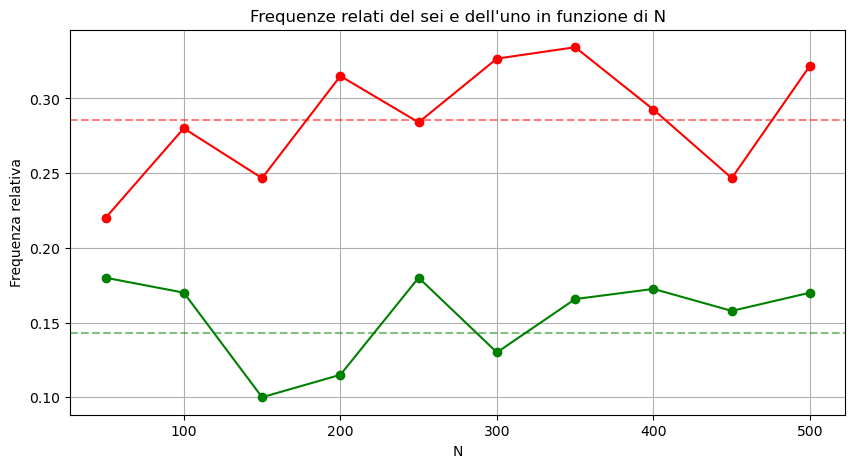

In [13]:
def lanci_dado(N):
    array = np.random.choice([1,2,3,4,5,6], size=N, p=(1/7,1/7,1/7,1/7,1/7,2/7))
    return array

intervalli = np.arange(50,501,50)
f_sei = [np.mean(lanci_dado(n) == 6) for n in intervalli]
f_uno = [np.mean(lanci_dado(n) == 1) for n in intervalli]


plt.figure(figsize=(10,5))
plt.plot(intervalli,f_sei, marker='o', color='red', label='Frequenza sei')
plt.plot(intervalli, f_uno, marker='o', color='green', label='Frequenza uno')
plt.axhline(y=1/7, color='green', linestyle='--', alpha=0.5, label='Valore atteso uno')
plt.axhline(y=2/7, color='red', linestyle='--', alpha=0.5, label='Valore atteso sei')
plt.title("Frequenze relati del sei e dell'uno in funzione di N")
plt.xlabel('N')
plt.ylabel('Frequenza relativa')
plt.grid(True)
plt.tight_layout
plt.show()

## Esercizio 3

Si consideri la seguente matrice di dimensione **4 × 5**, che rappresenta misure
raccolte in **4 giorni consecutivi** (righe) e in **5 fasce orarie** (colonne):

|     | F1 | F2 | F3 | F4 | F5 |
|-----|----|----|----|----|----|
| G1  | 12 | 15 | 14 | 16 | 18 |
| G2  | 11 | 14 | 13 | 15 | 17 |
| G3  | 13 | 16 | 15 | 17 | 19 |
| G4  | 10 | 13 | 12 | 14 | 16 |


1. Crea la matrice `M` come array NumPy e calcola:
   - la media di ciascuna riga
   - la media di ciascuna colonna
2. Crea una nuova matrice `N` ottenuta sottraendo a ogni elemento di `M`
   la media della **sua colonna**.
3. Individua la posizione (riga, colonna) del valore massimo di `N`
   e stampala.



In [8]:
numeri = np.array([12,15,14,16,18,11,14,13,15,17,13,16,15,17,19,10,13,12,14,16])
M = numeri.reshape(4,5)
media_r = np.mean(M, axis=1)
media_c = np.mean(M, axis=0)

print("Media righe:", media_r)
print("Media colonne:", media_c)

N = M - media_c

idx = np.argmax(N)
riga, colonna = np.unravel_index(idx, N.shape)

print(f"\nMatrice N:\n{N}")
print(f"\nValore massimo: {N[riga, colonna]:.2f} in posizione ({riga}, {colonna})")

Media righe: [15. 14. 16. 13.]
Media colonne: [11.5 14.5 13.5 15.5 17.5]

Matrice N:
[[ 0.5  0.5  0.5  0.5  0.5]
 [-0.5 -0.5 -0.5 -0.5 -0.5]
 [ 1.5  1.5  1.5  1.5  1.5]
 [-1.5 -1.5 -1.5 -1.5 -1.5]]

Valore massimo: 1.50 in posizione (2, 0)


In [3]:
# =========================
# (Setup) creazione dataset
# =========================
### Creazione del dataset `students.csv` (da eseguire una sola volta)

def make_shipments_csv(filename="shipments.csv", n=80, seed=0):
    rng = np.random.default_rng(seed)

    shipment_id = [f"S{1000+i}" for i in range(n)]
    carrier = rng.choice(["AdriaticLog", "NordCargo", "BlueRail", "FastShip"], size=n, p=[0.35, 0.25, 0.25, 0.15])
    month = rng.choice([f"2025-{m:02d}" for m in range(1, 13)], size=n)

    weight_kg = rng.integers(200, 5000, size=n)
    distance_km = rng.integers(50, 1800, size=n)
    fuel_l = (distance_km / rng.uniform(4.5, 8.5, size=n)).round(2)   # litri consumati
    delay_days = rng.integers(-1, 8, size=n)                          # -1 = in anticipo
    on_time = (delay_days <= 0).astype(int)

    df = pd.DataFrame({
        "shipment_id": shipment_id,
        "carrier": carrier,
        "month": month,
        "weight_kg": weight_kg,
        "distance_km": distance_km,
        "fuel_l": fuel_l,
        "delay_days": delay_days,
        "on_time": on_time
    })

    # sporco il dataset con mancanti
    miss1 = rng.choice(df.index, size=max(1, n//20), replace=False)
    miss2 = rng.choice(df.index.difference(miss1), size=max(1, n//20), replace=False)
    df.loc[miss1, "fuel_l"] = np.nan
    df.loc[miss2, "delay_days"] = np.nan

    df.to_csv(filename, index=False)
    return df

df = make_shipments_csv("shipments.csv", n=80, seed=0)
print(df.head())

  shipment_id      carrier    month  weight_kg  distance_km  fuel_l  \
0       S1000     BlueRail  2025-11       3320          883  152.80   
1       S1001  AdriaticLog  2025-10       1852          716  136.38   
2       S1002  AdriaticLog  2025-05       1285          804  111.82   
3       S1003  AdriaticLog  2025-06       2265          802  151.88   
4       S1004     BlueRail  2025-06       4391          599   87.95   

   delay_days  on_time  
0         2.0        0  
1         3.0        0  
2         3.0        0  
3         5.0        0  
4         3.0        0  


# Esercizio 4

Si consideri il file CSV `shipments.csv`, che contiene informazioni su alcune spedizioni.
Il dataset presenta valori mancanti e diverse variabili quantitative e categoriche.

Svolgere le seguenti richieste:

1. Caricare il dataset in un DataFrame pandas e determinare il numero di valori mancanti per ciascuna colonna.
2. Eliminare dal dataset tutte le righe che contengono almeno un valore mancante.
3. Creare una nuova colonna `eff_km_per_l`, definita come il rapporto tra `distance_km` e `fuel_l`.
4. Filtrare le spedizioni con `weight_kg > 2500` e `eff_km_per_l > 6.5` e stampare il numero di righe ottenute.
5. Rappresentare con un grafico a barre le 10 spedizioni con il valore più alto di `eff_km_per_l`.

Valori mancanti per colonna: shipment_id    0
carrier        0
month          0
weight_kg      0
distance_km    0
fuel_l         4
delay_days     4
on_time        0
dtype: int64
Numero di righe df_filtered: 20


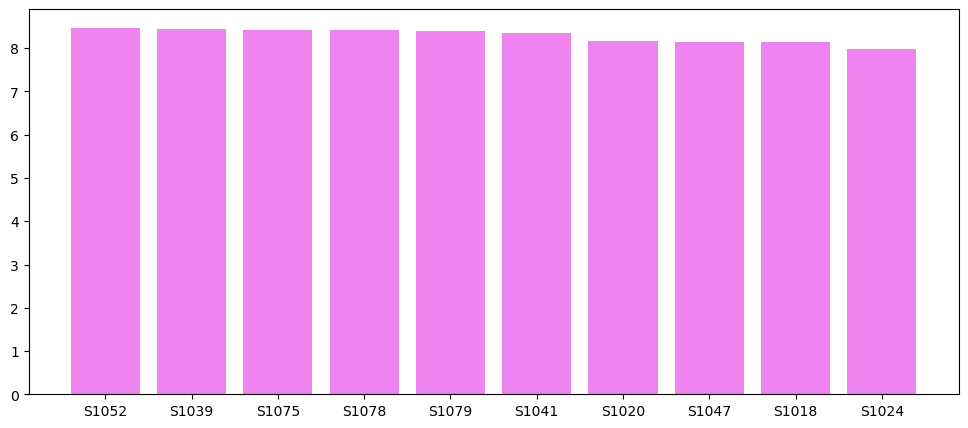

In [6]:
# 1
df = pd.read_csv('shipments.csv')
print(f"Valori mancanti per colonna: {df.isnull().sum()}")

# 2
df = df.dropna()

# 3
df = df[df['fuel_l']>0]
df['eff_km_per_l'] = df['distance_km']/df['fuel_l']

# 4
df_filtered = df[(df['weight_kg']>2500) & (df['eff_km_per_l']>6.5)]
print(f"Numero di righe df_filtered: {df_filtered.shape[0]}")

# 5
top10 = df.nlargest(10, 'eff_km_per_l')
plt.figure(figsize=(12,5))
plt.bar(top10['shipment_id'], top10['eff_km_per_l'], color='violet')
plt.show()

# Esercizio 5

Si utilizzi lo stesso dataset `shipments.csv`, opportunamente pulito come nell’esercizio precedente.

Svolgere le seguenti richieste:

1. Determinare il numero di righe e di colonne del dataset ed eliminare la colonna `shipment_id`.
2. Individuare il `carrier` più frequente nel dataset.
3. Calcolare la media di `delay_days` per ciascun `carrier` e ordinare i risultati dal valore medio più alto al più basso.
4. Rappresentare la distribuzione di `delay_days` per ciascun `carrier` mediante un boxplot.
5.  Calcolare la percentuale di spedizioni puntuali (`on_time = 1`) e non puntuali (`on_time = 0`)
**usando una list comprehension**, e rappresentare tali percentuali con un grafico a torta (pie chart).


Numero di righe e colonne: (72, 9)

Carrier più frequente: AdriaticLog


C:\Users\Viola\AppData\Local\Temp\ipykernel_13952\2413990015.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=carriers)


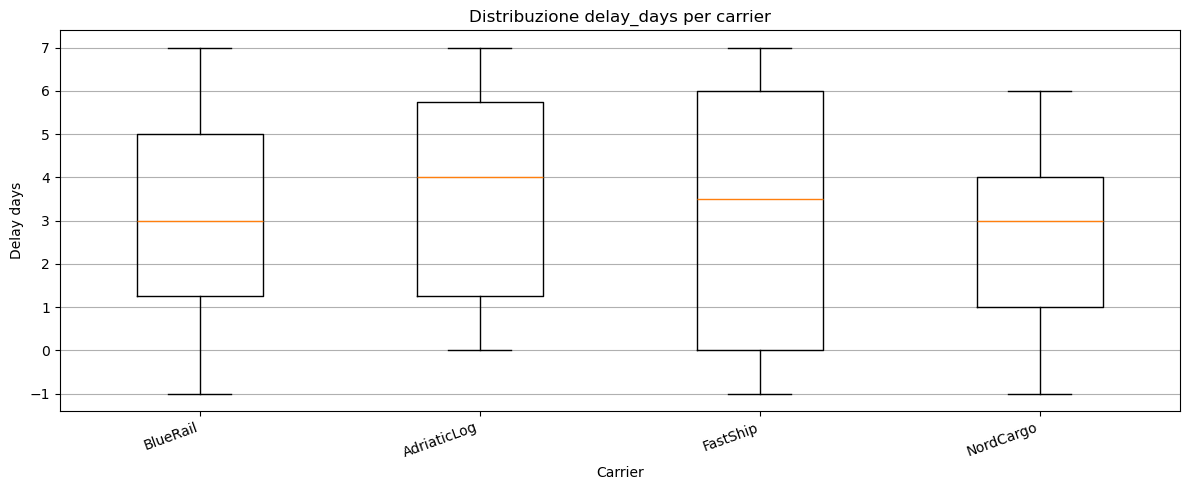

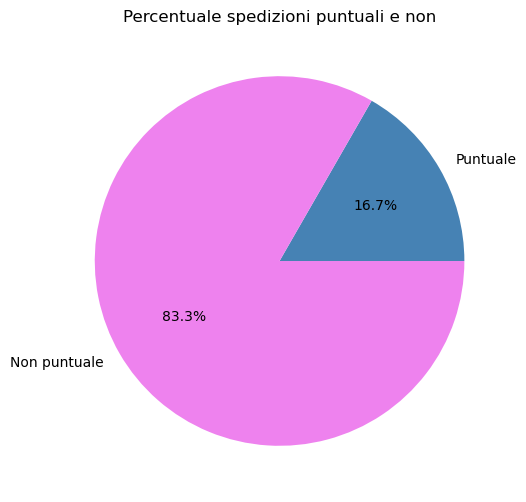

In [7]:
# 1
print(f"Numero di righe e colonne: {df.shape}")
df = df.drop(columns=['shipment_id'])
# 2
print(f"\nCarrier più frequente: {df['carrier'].value_counts().idxmax()}")
# 3
media = df.groupby('carrier')['delay_days'].mean().sort_values(ascending=True)
# 4
carriers = df['carrier'].unique()
data = [df[df['carrier']==c]['delay_days'].values for c in carriers]
plt.figure(figsize=(12, 5))
plt.boxplot(data, labels=carriers)
plt.title('Distribuzione delay_days per carrier')
plt.xlabel('Carrier')
plt.ylabel('Delay days')
plt.xticks(rotation=20, ha='right')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()
# 5
percentuali = [round((df['on_time'] == v).mean() * 100, 1) for v in [1, 0]]

plt.figure(figsize=(6, 6))
plt.pie(percentuali, labels=['Puntuale', 'Non puntuale'], autopct='%1.1f%%', colors=['steelblue', 'violet'])
plt.title('Percentuale spedizioni puntuali e non')
plt.show()

## Esercizio 6

Hai a disposizione il dataset di coppie `(x, y)` qui sotto riportato.  

1. Stima i parametri della retta del tipo  

   $$
   y = a \cdot x + b
   $$  

2. Plotta i punti originali e la retta ottenuta.  

3. Calcola **MAE** (Mean Absolute Error) e **RMSE** (Root Mean Squared Error) tra i valori reali `y` e quelli stimati dal modello, dove:  

   $$
   \text{MAE} = \frac{1}{n}\sum_{i=1}^{n} \lvert y_i - \hat{y}_i \rvert
   $$  

   $$
   \text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
   $$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

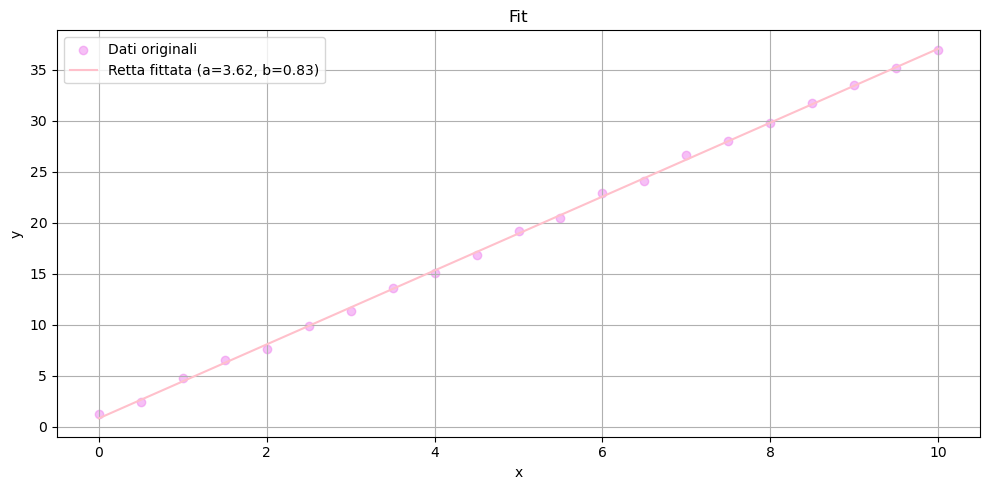

MAE: 0.2200
RMSE: 0.2624


In [2]:
x = np.array([
  0.0, 0.5, 1.0, 1.5, 2.0, 2.5,
  3.0, 3.5, 4.0, 4.5, 5.0, 5.5,
  6.0, 6.5, 7.0, 7.5, 8.0, 8.5,
  9.0, 9.5, 10.0
])

y = np.array([
   1.2,  2.4,  4.8,  6.5,  7.6,  9.9,
  11.3, 13.6, 15.1, 16.8, 19.2, 20.5,
  22.9, 24.1, 26.6, 28.0, 29.8, 31.7,
  33.5, 35.2, 36.9
])
# 1
def retta(x, a, b):
    return a*x + b

params,cov = curve_fit(retta, x, y)
a,b = params
# 2
y_fit = retta(x,a,b)

plt.figure(figsize=(10,5))
plt.scatter(x, y, color='violet', alpha=0.5, label='Dati originali')
plt.plot(x, y_fit, color='pink', label=f'Retta fittata (a={a:.2f}, b={b:.2f})')
plt.title('Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3
MAE = np.mean(np.abs(y - y_fit))
RMSE = np.sqrt(np.mean((y - y_fit)**2))
print(f"MAE: {MAE:.4f}")
print(f"RMSE: {RMSE:.4f}")